In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("case1_telecom_kmeans_1000.csv")
df.head()

,MonthlyCharges,Tenure,DataUsageGB,CallDurationMin
0,402,29,4,342
1,570,25,7,397
2,406,43,6,246
3,371,51,6,277
4,488,34,4,323


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   MonthlyCharges   999 non-null    int64
 1   Tenure           999 non-null    int64
 2   DataUsageGB      999 non-null    int64
 3   CallDurationMin  999 non-null    int64
dtypes: int64(4)
memory usage: 31.3 KB


In [30]:
df.columns

Index(['MonthlyCharges', 'Tenure', 'DataUsageGB', 'CallDurationMin',
       'Cluster'],
      dtype='object')

In [13]:
X = df[['MonthlyCharges', 'Tenure', 'DataUsageGB', 'CallDurationMin']]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

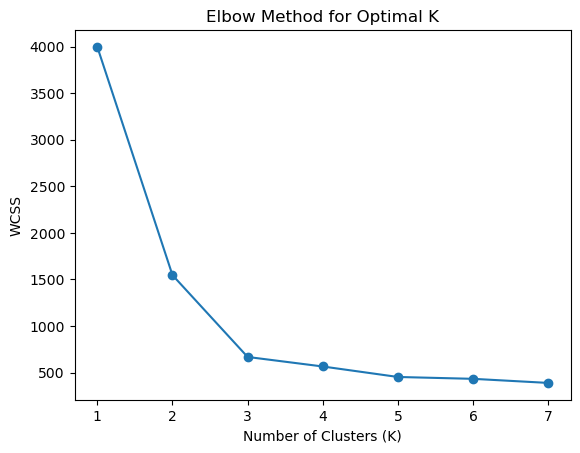

In [25]:
wcss = []

for k in range (1,8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,8), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
df

,MonthlyCharges,Tenure,DataUsageGB,CallDurationMin,Cluster
0,402,29,4,342,2
1,570,25,7,397,2
2,406,43,6,246,2
3,371,51,6,277,2
4,488,34,4,323,2
...,...,...,...,...,...
994,739,5,1,127,1
995,928,4,6,169,1
996,735,10,4,271,1
997,1107,1,4,248,1


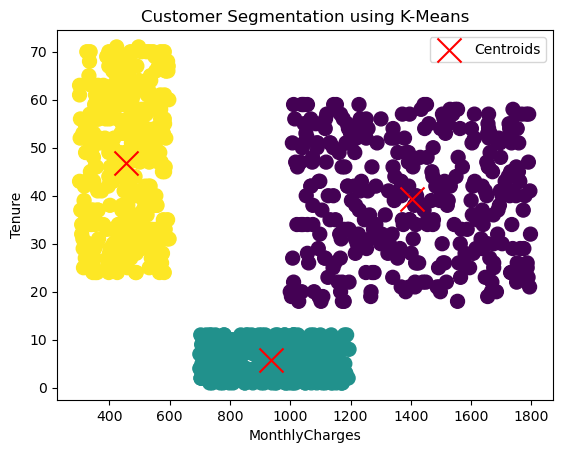

In [28]:
#Visualize the cluster
plt.figure()

plt.scatter(
    df['MonthlyCharges'], df['Tenure'], c=df['Cluster'], cmap='viridis', s=100)
plt.xlabel("MonthlyCharges")
plt.ylabel("Tenure")
plt.title("Customer Segmentation using K-Means")

#Now plotting centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:,0], centroids[:,1], s=300, c='red', marker='x', label='Centroids')
plt.legend()
plt.show()

In [29]:
# New customer data
new_customer = [[85, 6, 120, 300]]

# Scale new data using the SAME scaler
new_customer_scaled = scaler.transform(new_customer)

# Predict cluster
predicted_cluster = kmeans.predict(new_customer_scaled)

print("New customer belongs to Cluster:", predicted_cluster[0])

# Business interpretation
if predicted_cluster[0] == 0:
    print("High-Value Customer – Premium plans & loyalty rewards recommended")
elif predicted_cluster[0] == 1:
    print("Mid-Value Customer – Personalized discounts recommended")
else:
    print("Low-Value Customer – Budget-friendly plans recommended")


New customer belongs to Cluster: 0
High-Value Customer – Premium plans & loyalty rewards recommended


C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
